In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Carica tutti e tre gli universi
returns_eu = pd.read_csv(r'C:\Users\ffran\monte-carlo-sim\data\raw\returns_europe.csv',
                          index_col=0, parse_dates=True)
returns_us = pd.read_csv(r'C:\Users\ffran\monte-carlo-sim\data\raw\returns_america.csv',
                          index_col=0, parse_dates=True)
returns_as = pd.read_csv(r'C:\Users\ffran\monte-carlo-sim\data\raw\returns_asia.csv',
                          index_col=0, parse_dates=True)

# Allinea i tre dataset sullo stesso indice
combined = returns_eu.join(returns_us, how='inner').join(returns_as, how='inner')
combined = combined.dropna()

print(f"Europa:  {returns_eu.shape[1]} asset")
print(f"America: {returns_us.shape[1]} asset")
print(f"Asia:    {returns_as.shape[1]} asset")
print(f"\nGlobale dopo allineamento: {combined.shape[1]} asset x {len(combined)} giorni")
print(f"Periodo: {combined.index[0].date()} — {combined.index[-1].date()}")

Europa:  68 asset
America: 65 asset
Asia:    28 asset

Globale dopo allineamento: 161 asset x 2747 giorni
Periodo: 2015-01-06 — 2025-12-31


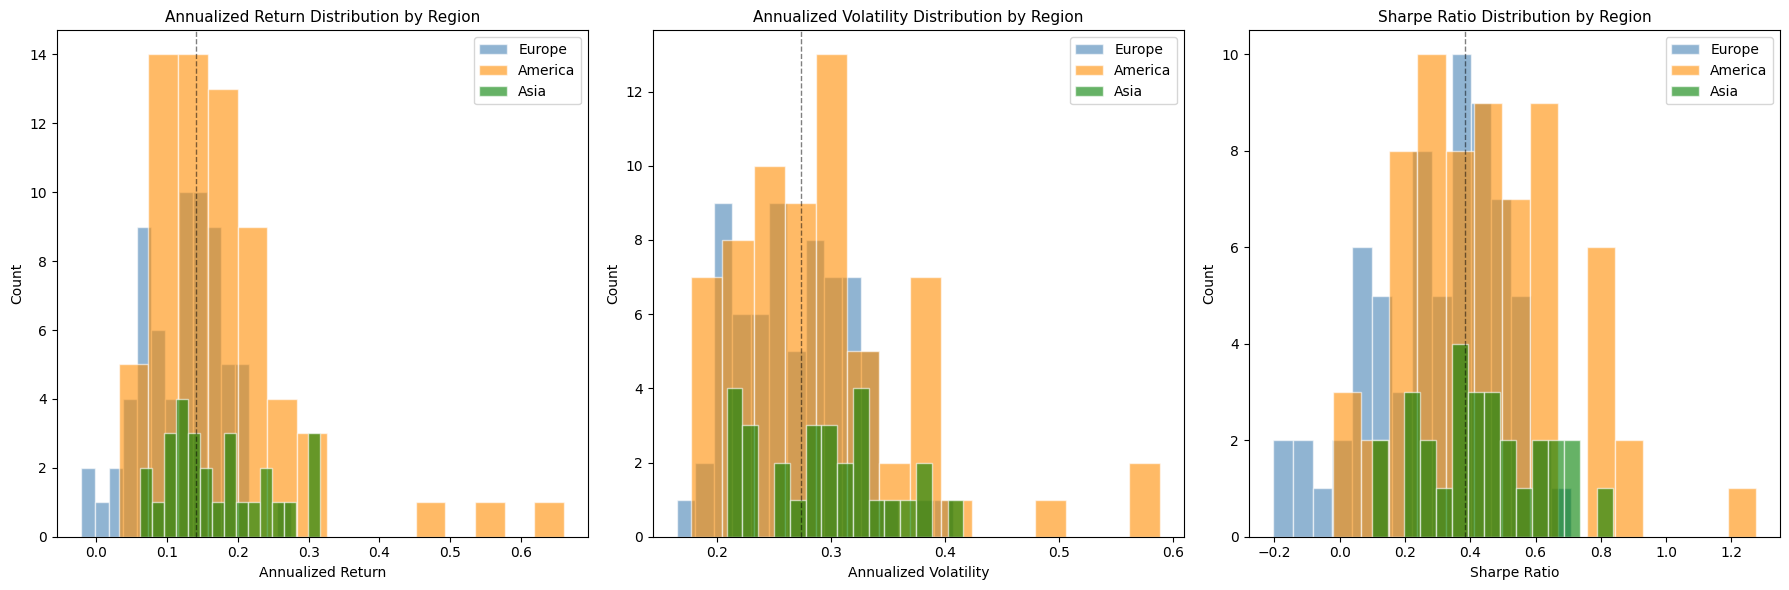

MEDIAN STATISTICS BY REGION:
         Return  Volatility  Sharpe
Region                             
America   0.157       0.274   0.426
Asia      0.160       0.294   0.432
Europe    0.132       0.266   0.342


In [5]:
# Cella 1 — Statistiche comparative per continente
import os
os.makedirs('../results', exist_ok=True)

# Parametri annualizzati per continente
def get_stats(returns, label):
    mu = returns.mean() * 252
    sigma = returns.std() * np.sqrt(252)
    sharpe = (mu - 0.04) / sigma
    return pd.DataFrame({
        'Return': mu,
        'Volatility': sigma,
        'Sharpe': sharpe,
        'Region': label
    })

stats_eu = get_stats(returns_eu, 'Europe')
stats_us = get_stats(returns_us, 'America')
stats_as = get_stats(returns_as, 'Asia')
stats_all = pd.concat([stats_eu, stats_us, stats_as])

# Plot comparativo
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = {'Europe': 'steelblue', 'America': 'darkorange', 'Asia': 'green'}

for ax, (metric, label) in zip(axes, [('Return', 'Annualized Return'), 
                                        ('Volatility', 'Annualized Volatility'),
                                        ('Sharpe', 'Sharpe Ratio')]):
    for region, color in colors.items():
        data = stats_all[stats_all['Region'] == region][metric]
        ax.hist(data, bins=15, alpha=0.6, color=color, label=region, edgecolor='white')
    ax.set_title(f'{label} Distribution by Region', fontsize=11)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend()
    ax.axvline(x=stats_all[metric].median(), color='black', 
               linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('../results/global_stats_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistiche
print("MEDIAN STATISTICS BY REGION:")
print(stats_all.groupby('Region')[['Return', 'Volatility', 'Sharpe']].median().round(3))

In [7]:
# Cella 2 — Ottimizzazione globale con src/optimizer
import sys
sys.path.append(r'C:\Users\ffran\monte-carlo-sim')
from src.optimizer import max_sharpe, min_volatility, efficient_frontier

mu_global = combined.mean().values * 252
cov_global = combined.cov().values * 252

best_global = max_sharpe(mu_global, cov_global, rf=0.04)
minvol_global = min_volatility(mu_global, cov_global)
frontier_global = efficient_frontier(mu_global, cov_global, rf=0.04)

print(f"Global Max Sharpe:")
print(f"  Return:     {best_global['return']:.2%}")
print(f"  Volatility: {best_global['volatility']:.2%}")
print(f"  Sharpe:     {best_global['sharpe']:.3f}")

print(f"\nGlobal Min Vol:")
print(f"  Return:     {minvol_global['return']:.2%}")
print(f"  Volatility: {minvol_global['volatility']:.2%}")

# Allocazione per regione
eu_tickers = list(returns_eu.columns)
us_tickers = list(returns_us.columns)
as_tickers = list(returns_as.columns)

w_series = pd.Series(best_global['weights'], index=combined.columns)
alloc_eu = w_series[w_series.index.isin(eu_tickers)].sum()
alloc_us = w_series[w_series.index.isin(us_tickers)].sum()
alloc_as = w_series[w_series.index.isin(as_tickers)].sum()

print(f"\nRegional Allocation:")
print(f"  Europe:  {alloc_eu:.2%}")
print(f"  America: {alloc_us:.2%}")
print(f"  Asia:    {alloc_as:.2%}")

Global Max Sharpe:
  Return:     31.93%
  Volatility: 16.48%
  Sharpe:     1.694

Global Min Vol:
  Return:     9.61%
  Volatility: 9.36%

Regional Allocation:
  Europe:  15.96%
  America: 49.71%
  Asia:    34.33%


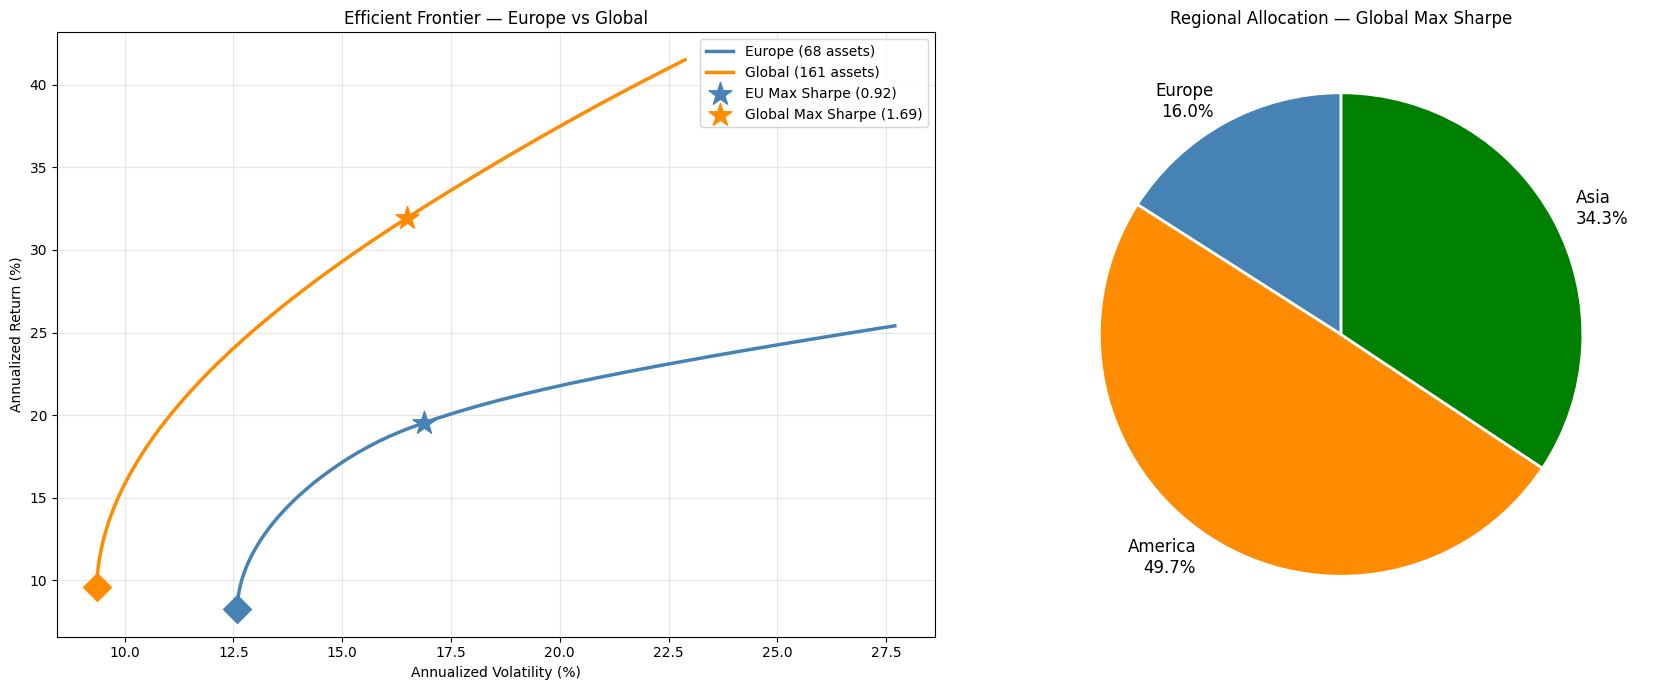

In [9]:
# Cella 3 — Confronto frontiere Europa vs Globale

import sys
sys.path.append(r'C:\Users\ffran\monte-carlo-sim')
from src.optimizer import max_sharpe, min_volatility, efficient_frontier

# Ricalcola frontiera europea per confronto
mu_eu = returns_eu.mean().values * 252
cov_eu = returns_eu.cov().values * 252
best_eu = max_sharpe(mu_eu, cov_eu, rf=0.04)
minvol_eu = min_volatility(mu_eu, cov_eu)
frontier_eu = efficient_frontier(mu_eu, cov_eu, rf=0.04)

valid_eu = ~np.isnan(frontier_eu['volatility'])
valid_g = ~np.isnan(frontier_global['volatility'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Frontiere
axes[0].plot(frontier_eu['volatility'][valid_eu] * 100,
             frontier_eu['target_return'][valid_eu] * 100,
             color='steelblue', linewidth=2.5, label='Europe (68 assets)')
axes[0].plot(frontier_global['volatility'][valid_g] * 100,
             frontier_global['target_return'][valid_g] * 100,
             color='darkorange', linewidth=2.5, label='Global (161 assets)')

# Punti ottimali
axes[0].scatter(best_eu['volatility'] * 100, best_eu['return'] * 100,
                color='steelblue', s=300, zorder=5, marker='*',
                label=f'EU Max Sharpe ({best_eu["sharpe"]:.2f})')
axes[0].scatter(best_global['volatility'] * 100, best_global['return'] * 100,
                color='darkorange', s=300, zorder=5, marker='*',
                label=f'Global Max Sharpe ({best_global["sharpe"]:.2f})')
axes[0].scatter(minvol_eu['volatility'] * 100, minvol_eu['return'] * 100,
                color='steelblue', s=200, zorder=5, marker='D')
axes[0].scatter(minvol_global['volatility'] * 100, minvol_global['return'] * 100,
                color='darkorange', s=200, zorder=5, marker='D')

axes[0].set_xlabel('Annualized Volatility (%)')
axes[0].set_ylabel('Annualized Return (%)')
axes[0].set_title('Efficient Frontier — Europe vs Global', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Allocazione regionale a torta
axes[1].pie([alloc_eu, alloc_us, alloc_as],
            labels=[f'Europe\n{alloc_eu:.1%}',
                    f'America\n{alloc_us:.1%}',
                    f'Asia\n{alloc_as:.1%}'],
            colors=['steelblue', 'darkorange', 'green'],
            autopct='', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Regional Allocation — Global Max Sharpe', fontsize=12)

plt.tight_layout()
plt.savefig('../results/global_efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()